# Modelo de RL 
### Optimzación de una tryectoria a través de un potencial


In [ ]:
pip install numpy matplotlib gymnasium stable_baselines3

### Implementación del entorno
El entorno es una superclase que hereda de la clase gym.Env 
Toma de inputs la función del potencial a optimizar, el número máximo de pasos por iteración, intervalo temporal, 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.registration import registry

In [ ]:
# ------------------ POTENCIAL ------------------
def potencial_ej(x, y):
    V = np.exp(-(x**2 + y**2)/3)
    return V


class ParticlePotentialEnv(gym.Env):

    def __init__(self,
                 potential_fn=None,
                 max_steps=500,
                 dt=0.02,
                 speed=0.1,
                 goal_radius=0.02,
                 render_mode=None):

        self.potential_fn = potential_fn or potencial_ej

        self.max_steps = max_steps
        self.dt = dt
        self.speed = speed
        self.goal_radius = goal_radius
        self.render_mode = render_mode

        # Acción: ángulo θ
        self.action_space = spaces.Box(
            low=np.array([-np.pi], dtype= np.float32),
            high=np.array([ np.pi], dtype = np.float32),
            dtype=np.float32
        )

        # Estado: pos (2) + vector al objetivo (2)
        self.observation_space = spaces.Box(
            low=-1e6,
            high=1e6,
            shape=(4,),
            dtype=np.float32
        )

        self.reset()

    def _obs(self):
        return np.concatenate([self.pos, self.goal - self.pos]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = np.random.uniform(0, 1, size=2).astype(np.float32)
        self.goal = np.random.uniform(0, 1, size=2).astype(np.float32)

        self.steps = 0
        self.traj = [self.pos.copy()]

        return self._obs(), {}

    def step(self, action):
        theta = float(action[0])

        prev_pos = self.pos.copy()

        # dinámica (velocidad fija)
        direction = np.array([np.cos(theta), np.sin(theta)])
        self.pos += self.speed * direction * self.dt

        self.steps += 1
        self.traj.append(self.pos.copy())

        # métricas
        prev_dist = np.linalg.norm(self.goal - prev_pos)
        dist = np.linalg.norm(self.goal - self.pos)
        V = self.potential_fn(*self.pos)

        # reward (clave)
        reward = -V + 3.0 * (prev_dist - dist)

        # condiciones
        done = dist < self.goal_radius
        if done:
            reward += 5

        out = np.any((self.pos < -0.1) | (self.pos > 1.1))
        if out:
            reward -= 5

        truncated = self.steps >= self.max_steps or out

        if self.render_mode == "human":
            self.render()

        return self._obs(), reward, done, truncated, {}

    def render(self):
        if not hasattr(self, "fig"):
            self.fig, self.ax = plt.subplots()
            plt.ion()

        self.ax.clear()
        t = np.array(self.traj)

        if len(t) > 1:
            self.ax.plot(t[:,0], t[:,1], "c-")

        self.ax.plot(*self.goal, "b*")
        self.ax.plot(*self.pos, "ro")

        self.ax.set_xlim(0,1)
        self.ax.set_ylim(0,1)
        self.ax.set_title(f"step {self.steps}")

        plt.pause(0.001)

if "ParticlePotential-v0" not in registry:
    gym.register(
        id="ParticlePotential-v0",
        entry_point=__name__ + ":ParticlePotentialEnv"
    )

In [19]:
# ------------------ TRAIN ------------------
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

def train(steps=200_000, n_envs=4):    

    def make_env():
        return ParticlePotentialEnv()

    env = DummyVecEnv([make_env for _ in range(n_envs)])

    model = SAC("MlpPolicy", env, device="cuda", verbose=0)
    print(f'Usando {model.device}')
    model.learn(total_timesteps=steps)
    model.save("models/particle_sac")

### Entrenamiento del modelo


In [ ]:
import time

# Parametros para la funcion de entrenamiento
n_pasos = 20000
n_entornos = 2


#Entrenamiento 
t0 = time.time()
train(steps= n_pasos, n_envs= n_entornos)  # usa el nombre real de tu función
tf = time.time()
t = tf - t0
print(f"Tiempo de entrenamiento: {t}")



Usando cuda
Tiempo de entrenamiento: 135.554541349411


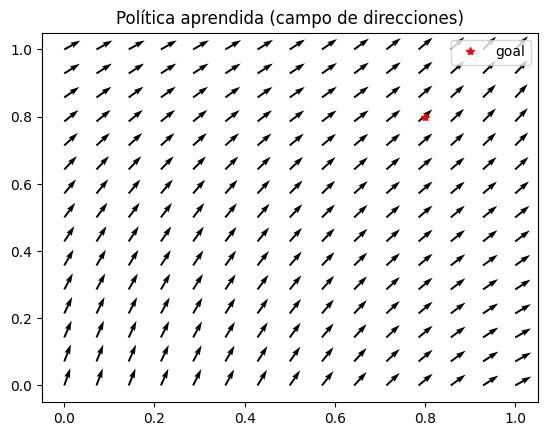

In [21]:
env = ParticlePotentialEnv()
model = SAC.load("models/particle_sac")

grid_size = 15
xs = np.linspace(0,1,grid_size)
ys = np.linspace(0,1,grid_size)

U, V = [], []

goal = np.array([0.8, 0.8])  # fijo para visualizar

for y in ys:
    u_row, v_row = [], []
    for x in xs:
        env.pos = np.array([x,y])
        env.goal = goal
        obs = env._obs()

        action, _ = model.predict(obs, deterministic=True)
        theta = action[0]

        u_row.append(np.cos(theta))
        v_row.append(np.sin(theta))
    U.append(u_row)
    V.append(v_row)

X, Y = np.meshgrid(xs, ys)

plt.figure()
plt.quiver(X, Y, U, V)
plt.plot(*goal, 'r*', label="goal")
plt.title("Política aprendida (campo de direcciones)")
plt.legend()
plt.show()